# **MNIST Digit Classification using PCA and LDA**

In [1]:
# DIGITAL IMAGE PROCESSING — DATASET LOADING AND IMAGE PREPROCESSING

# Import Libraries

import matplotlib.pyplot as plt
import numpy as np
from tensorflow import keras

# 1. Load the MNIST Dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("--- Check Image Sizes ---")
print(f"Training images size (x_train.shape): {x_train.shape}")
print(f"Testing images size (x_test.shape): {x_test.shape}")
print(f"Digital encoding data type: {x_train.dtype}\n")


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
--- Check Image Sizes ---
Training images size (x_train.shape): (60000, 28, 28)
Testing images size (x_test.shape): (10000, 28, 28)
Digital encoding data type: uint8



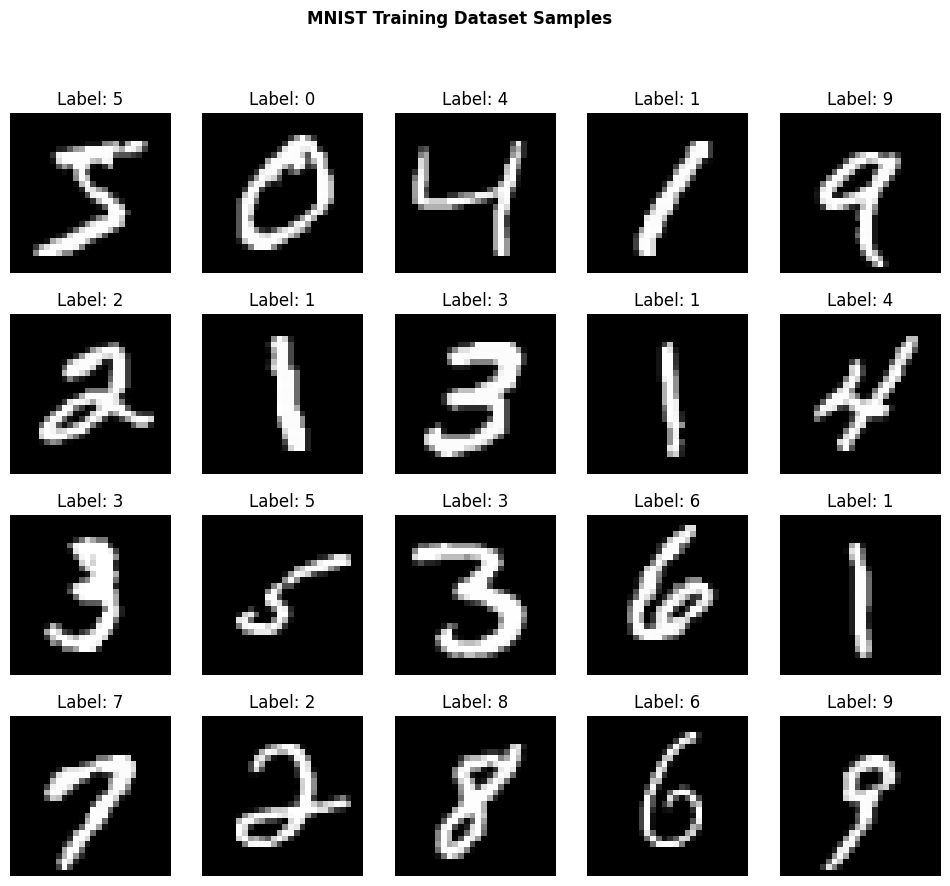

In [2]:
# 2. Visualize sample images
fig, axes = plt.subplots(nrows=4, ncols=5, figsize=(12, 10))
ax = axes.ravel()  # convert axes grid to a 1D array

for i in range(20):
    ax[i].imshow(x_train[i], cmap=plt.cm.gray)  # Explicit gray colormap
    ax[i].set_title(f"Label: {y_train[i]}")     # Show corresponding labels
    ax[i].axis('off')

plt.suptitle("MNIST Training Dataset Samples", fontsize=12, fontweight='bold')
plt.savefig('mnist_preprocessing_grid.png', dpi=100)
plt.show()

In [3]:
# 3. Normalize the images
x_train_norm = x_train.astype("float32") / 255
x_test_norm = x_test.astype("float32") / 255

print("--- Normalization Verification ---")
print(f"Original maximum pixel: {np.max(x_train)}")
print(f"Normalized maximum pixel: {np.max(x_train_norm)}")
print(f"New normalized data type: {x_train_norm.dtype}\n")


--- Normalization Verification ---
Original maximum pixel: 255
Normalized maximum pixel: 1.0
New normalized data type: float32



In [4]:

# 4. Flatten/Reshape images
num_features = x_train.shape[1] * x_train.shape[2] # 28 * 28 = 784 features

X_train_flat = x_train_norm.reshape(x_train_norm.shape[0], num_features)
X_test_flat = x_test_norm.reshape(x_test_norm.shape[0], num_features)

print("--- Flattening Verification ---")
print(f"Flattened training shape (X_train_flat.shape): {X_train_flat.shape}")
print(f"Flattened testing shape (X_test_flat.shape): {X_test_flat.shape}")
print("\n[SUCCESS] Dataset loading and preprocessing operations are complete!")


--- Flattening Verification ---
Flattened training shape (X_train_flat.shape): (60000, 784)
Flattened testing shape (X_test_flat.shape): (10000, 784)

[SUCCESS] Dataset loading and preprocessing operations are complete!


In [5]:
# ============================================================
# PCA FEATURE EXTRACTION
# ============================================================

from sklearn.decomposition import PCA

# 5. Apply PCA Dimensionality Reduction

num_components = 100

# Initialize PCA to keep 100 components
pca = PCA(n_components=num_components, svd_solver='randomized')

# Fit on the flattened training data and transform it
X_train_pca = pca.fit_transform(X_train_flat)

# Only transform the test set without fitting on test data to prevent data leakage
X_test_pca = pca.transform(X_test_flat)

print("--- PCA Dimensionality Reduction ---")
print("Original training shape:", X_train_flat.shape)
print("PCA training shape:", X_train_pca.shape)
print("Original testing shape:", X_test_flat.shape)
print("PCA testing shape:", X_test_pca.shape)
print(f"Total variance explained by 100 components: {np.sum(pca.explained_variance_ratio_):.4f}\n")


--- PCA Dimensionality Reduction ---
Original training shape: (60000, 784)
PCA training shape: (60000, 100)
Original testing shape: (10000, 784)
PCA testing shape: (10000, 100)
Total variance explained by 100 components: 0.9143



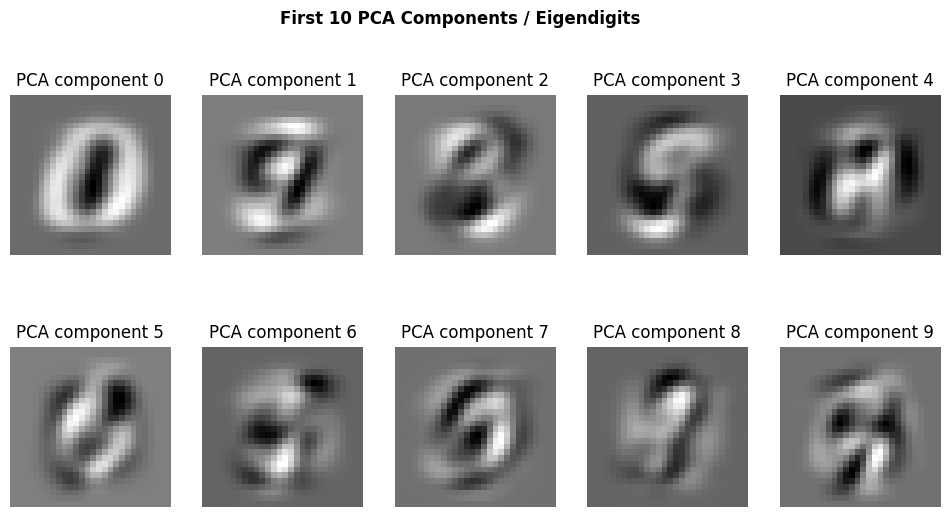

In [6]:
# 6. Visualize PCA Components/Eigendigits

# The principal components are stored in pca.components_ (shape: 100, 784)
eigendigits = pca.components_.reshape((num_components, 28, 28))

fig, axes = plt.subplots(2, 5, figsize=(12, 6))
ax = axes.ravel()

for i in range(10):
  # We use a gray colormap to show positive and negative weights in the eigenvector
    ax[i].imshow(eigendigits[i], cmap=plt.cm.gray)
    ax[i].set_title("PCA component {}".format(i))
    ax[i].axis("off")

plt.suptitle("First 10 PCA Components / Eigendigits", fontsize=12, fontweight="bold")
plt.savefig("pca_components_eigendigits.png", dpi=100)
plt.show()

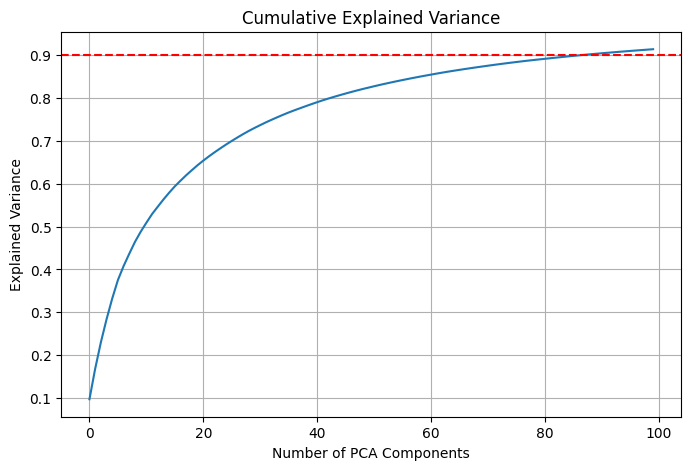

--- Explained Variance ---
Total explained variance using 100 components:
0.91430557


In [7]:
# 7. Plot cumulative explained variance

plt.figure(figsize=(8, 5))
plt.plot(pca.explained_variance_ratio_.cumsum())

# Add a reference line to see where we hit 90% variance (a common threshold)
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Variance Threshold')

plt.title("Cumulative Explained Variance")
plt.xlabel("Number of PCA Components")
plt.ylabel("Explained Variance")
plt.grid()
plt.savefig("pca_explained_variance.png", dpi=100)
plt.show()

print("--- Explained Variance ---")
print("Total explained variance using 100 components:")
print(pca.explained_variance_ratio_.cumsum()[-1])

In [8]:
# CLASSIFICATION WITH LDA

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 8. Train the LDA Classifier
print("--- Training LDA Classifier ---")
# Initialize the LDA model
lda_classifier = LinearDiscriminantAnalysis()

# Train the model using the PCA-reduced training features and their labels
lda_classifier.fit(X_train_pca, y_train)
print("LDA model trained successfully on PCA features.\n")

--- Training LDA Classifier ---
LDA model trained successfully on PCA features.



In [9]:
# 9. Predict test images
print("--- Generating Predictions ---")
# Predict the labels for the test dataset
y_pred = lda_classifier.predict(X_test_pca)
print(f"Predictions for {len(y_pred)} test images.\n")

--- Generating Predictions ---
Predictions for 10000 test images.



--- Classification Report ---
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       980
           1       0.89      0.96      0.92      1135
           2       0.92      0.81      0.86      1032
           3       0.87      0.87      0.87      1010
           4       0.87      0.90      0.88       982
           5       0.82      0.80      0.81       892
           6       0.92      0.92      0.92       958
           7       0.92      0.85      0.88      1028
           8       0.81      0.82      0.82       974
           9       0.81      0.89      0.85      1009

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



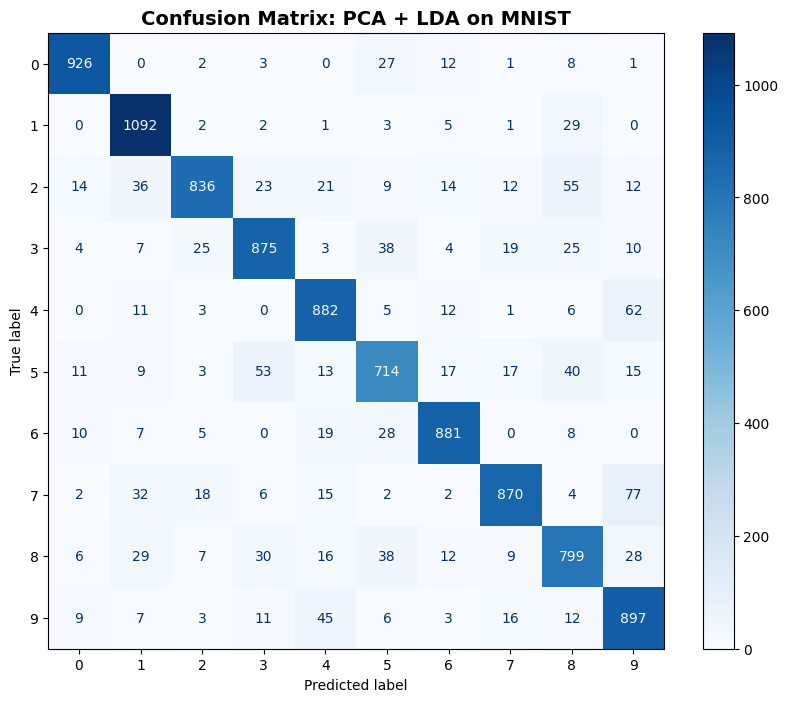

In [10]:
# 10. Evaluate classification performance
print("--- Classification Report ---")
# Generate a text report showing precision, recall, and f1-score
report = classification_report(y_test, y_pred)
print(report)

# Generate and plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lda_classifier.classes_)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')
plt.title("Confusion Matrix: PCA + LDA on MNIST", fontsize=14, fontweight='bold')
plt.show()

--- Visualizing Sample Predictions ---


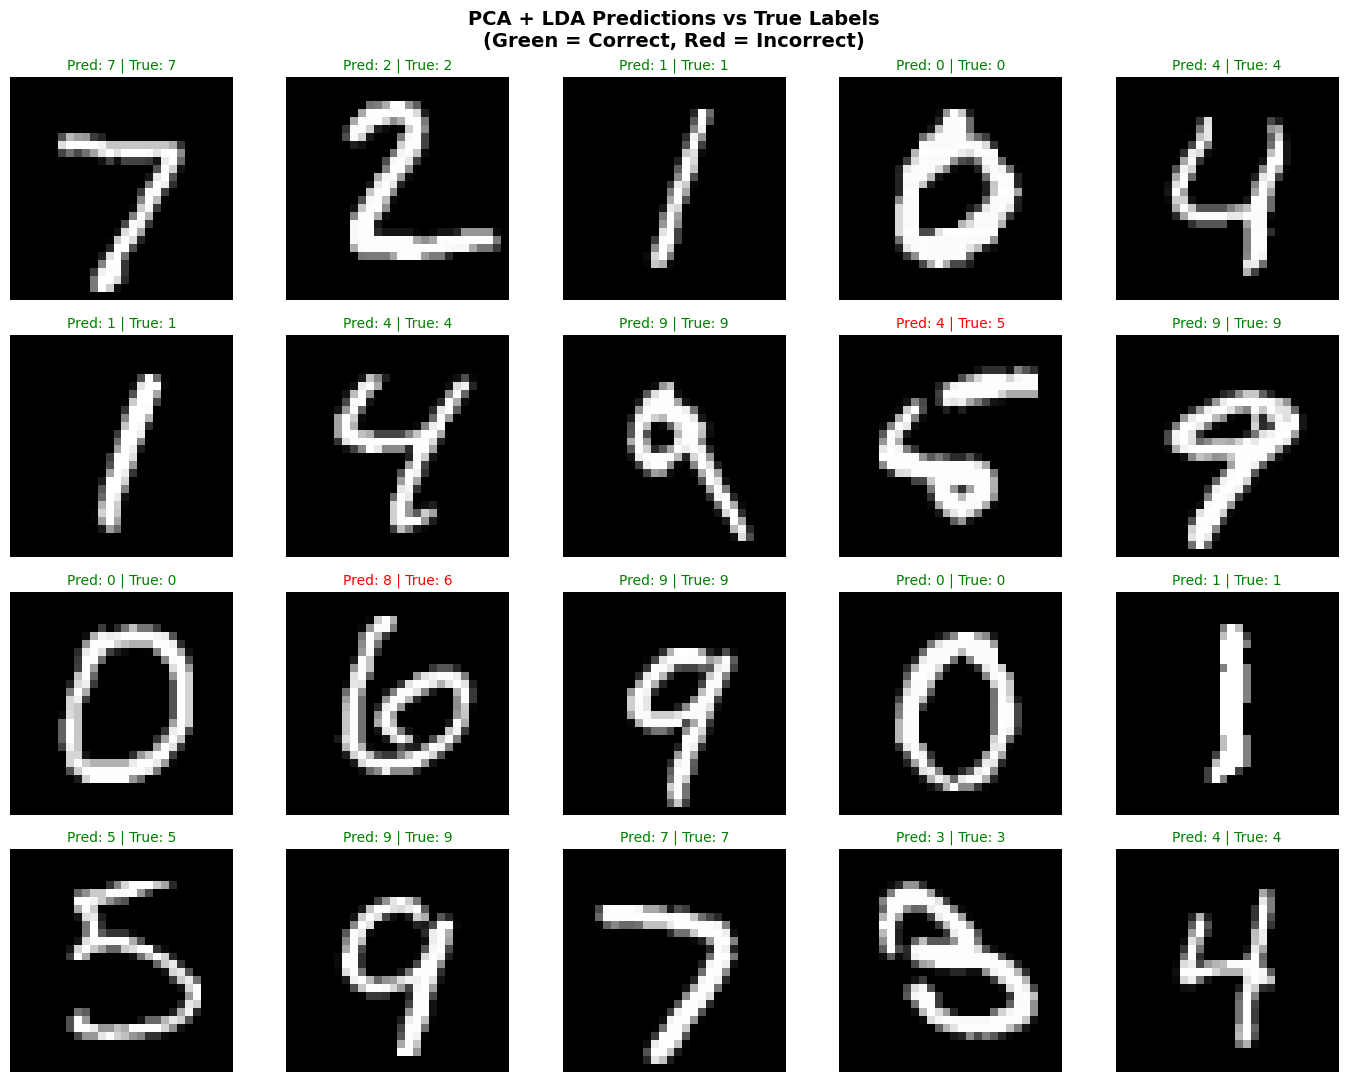

In [11]:
# 11. Visualize predictions
print("--- Visualizing Sample Predictions ---")
fig, axes = plt.subplots(nrows=4, ncols=5, figsize=(14, 11))
ax = axes.ravel()

for i in range(20):
    # Display the original unflattened test image
    ax[i].imshow(x_test[i], cmap=plt.cm.gray)

    # Check if the prediction was correct to color-code the title
    is_correct = y_pred[i] == y_test[i]
    text_color = 'green' if is_correct else 'red'

    ax[i].set_title(f"Pred: {y_pred[i]} | True: {y_test[i]}", color=text_color, fontsize=10)
    ax[i].axis('off')

plt.suptitle("PCA + LDA Predictions vs True Labels\n(Green = Correct, Red = Incorrect)",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# **Multi-Digit Segmentation**

Since MNIST digits are already pre-isolated making segmentation trivial, we present a way to segment an image of 4 digits stitched together

In [12]:
import cv2

# --- Generate a multi digit test image ---
# Stitch 4 random images from the original test dataset together horizontally
np.random.seed(17) # For reproducible results
random_indices = np.random.choice(len(x_test), 4, replace=False) #Generate a sample of 4 random numbers

# Extract 4 digits and their true labels
digits_to_stitch = [x_test[idx] for idx in random_indices]
true_labels = [y_test[idx] for idx in random_indices]

# Add horizontal spacing between digits to simulate a real string
padded_digits = []
spacing_pixels = 6 # Adjust this to change digit proximity

for img in digits_to_stitch:
    # Add black columns to the right of each digit
    padded = np.hstack((img, np.zeros((28, spacing_pixels), dtype=np.uint8)))
    padded_digits.append(padded)

# Concatenate them horizontally into one single image canvas
multi_digit_image = np.hstack(padded_digits)

In [13]:
# --- Thresholding ---
# We apply Otsu's thresholding to create a clean binary mask (0 or 255)
_, binary_mask = cv2.threshold(multi_digit_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)


# --- Bounding box detection ---
# cv2.findContours looks for continuous white shapes against the black background
contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Sort contours from left to right so we read the digits in correct order
contours = sorted(contours, key=lambda ctr: cv2.boundingRect(ctr)[0])

segmented_digits = []
bounding_boxes = []

print(f"Detected {len(contours)} potential digit segments.")

# --- Extraction, padding, and resizing ---
for i, ctr in enumerate(contours):
    # Get bounding box coordinates
    x, y, w, h = cv2.boundingRect(ctr)

    # Filter out tiny noise contours (e.g., random single pixels)
    if w < 3 or h < 3:
        continue

    bounding_boxes.append((x, y, w, h))

    # Crop the digit out of the original multi-digit image
    cropped = multi_digit_image[y:y+h, x:x+w]

    # MNIST digits are centered in a 28x28 square with a padding border.
    # To preserve aspect ratio, we pad the cropped image into a square first.
    max_dim = max(w, h)
    square_digit = np.zeros((max_dim, max_dim), dtype=np.uint8)

    # Center the cropped digit inside the square canvas
    dx = (max_dim - w) // 2
    dy = (max_dim - h) // 2
    square_digit[dy:dy+h, dx:dx+w] = cropped

    # Add an extra border margin (MNIST digits don't touch the absolute edge)
    border_pad = int(max_dim * 0.2)
    square_digit = cv2.copyMakeBorder(square_digit, border_pad, border_pad, border_pad, border_pad,
                                      cv2.BORDER_CONSTANT, value=0)

    # Resize exactly back to 28x28 pixels
    resized_digit = cv2.resize(square_digit, (28, 28), interpolation=cv2.INTER_AREA)

    # Normalize and flatten
    normalized_digit = resized_digit.astype("float32") / 255.0
    flattened_digit = normalized_digit.flatten() # Shape: (784,)

    segmented_digits.append(flattened_digit)



Detected 4 potential digit segments.


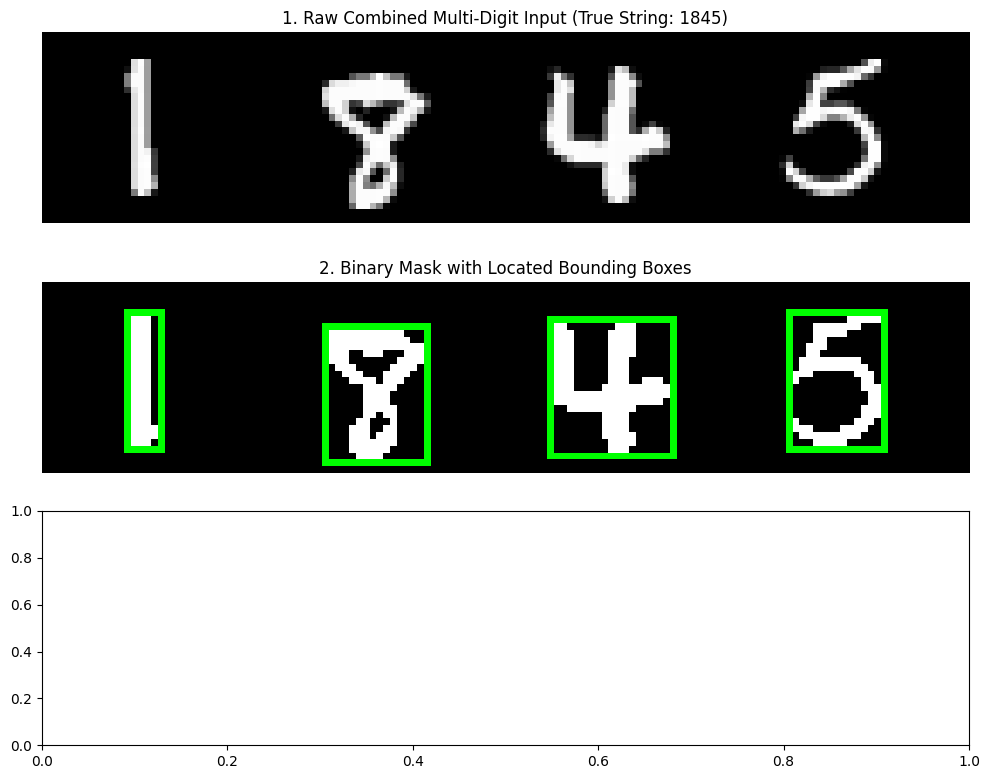

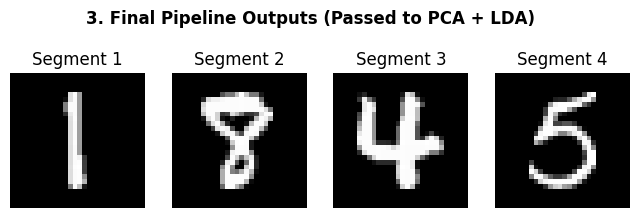

In [14]:
# --- Visualize the data ---
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 8))

# Raw Input Canvas
axes[0].imshow(multi_digit_image, cmap='gray')
axes[0].set_title(f"1. Raw Combined Multi-Digit Input (True String: {''.join(map(str, true_labels))})")
axes[0].axis('off')

# Binary Segmentation Visualized with Bounding Boxes
annotated_mask = cv2.cvtColor(binary_mask, cv2.COLOR_GRAY2RGB)
for (x, y, w, h) in bounding_boxes:
    # Draw a bounding box around each segment
    cv2.rectangle(annotated_mask, (x, y), (x+w, y+h), (0, 255, 0), 1)

axes[1].imshow(annotated_mask)
axes[1].set_title("2. Binary Mask with Located Bounding Boxes")
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Show Isolated, Resized Outputs ready for Classification
if len(segmented_digits) > 0:
    fig, axes = plt.subplots(nrows=1, ncols=len(segmented_digits), figsize=(len(segmented_digits)*2, 2))
    if len(segmented_digits) == 1:
        axes = [axes] # Handle single digit edge case
    for idx, flat_img in enumerate(segmented_digits):
        axes[idx].imshow(flat_img.reshape(28, 28), cmap='gray')
        axes[idx].set_title(f"Segment {idx+1}")
        axes[idx].axis('off')
    plt.suptitle("3. Final Pipeline Outputs (Passed to PCA + LDA)", y=1.15, fontweight='bold')
    plt.show()

In [15]:
#Testing with PCA and LDA
# Pass the pipeline outputs to classifier
for segment in segmented_digits:
    # Reshape to match the matrix requirements (1 sample, 784 features)
    feat_pca = pca.transform(segment.reshape(1, -1))
    prediction = lda_classifier.predict(feat_pca)
    print(f"Pipeline Predicted Digit: {prediction[0]}")

Pipeline Predicted Digit: 1
Pipeline Predicted Digit: 8
Pipeline Predicted Digit: 4
Pipeline Predicted Digit: 5
